In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Simulating the predator-prey system

Want to simulate predator-prey model data

$$
\begin{align}
    \dot{b} &= \epsilon_1b - \gamma_1bw\\
    \dot{w} &= -\epsilon_2w + \gamma_2bw.
\end{align}
$$

In [2]:
e1 = 1.
g1 = -0.1
e2 = -1.5
g2 = 0.1

def dX_dt(X, t=0):
    return np.array([
        e1*X[0] +   g1*X[0]*X[1] ,
        e2*X[1] + g2*X[0]*X[1]
    ])

Solution using explicit Euler as
$$
x^{n+1} = x^n + \tau f(x^n)
$$

In [3]:
y0 = np.array([10, 5])
t  = np.linspace(0,15,50000)
dt = t[1] - t[0]

ts = [0.0]
ys = [y0]
for i, _t in enumerate(t):
    yt = ys[i] + dt * dX_dt(ys[i])
    ys.append(yt)
    ts.append(ts[i] + dt)

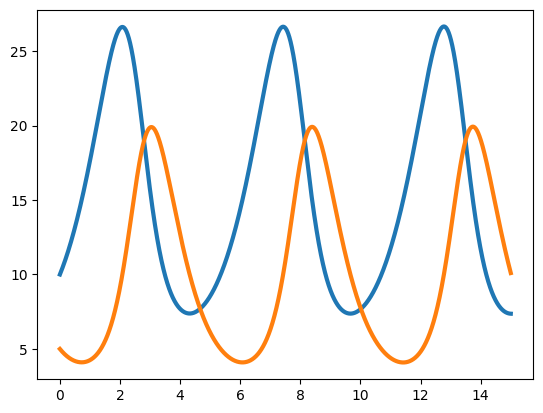

In [5]:
plt.plot(t, ys[:-1], linewidth=3)
plt.show()

## Learning the parameters

Assuming that we only observe data, can we get back the parameters $\epsilon_1$ and $\gamma_1$? Yes! Remember from the lecture that
$$
\pmb{\theta}^* = \arg\min_\theta \big\Vert \pmb{U}_t - X\pmb{\theta}\big\Vert_2^2.
$$

In the case of the ODE
$$
\begin{align}
    \dot{b} &= \epsilon_1b - \gamma_1bw\\
    \dot{w} &= -\epsilon_2w + \gamma_2bw.
\end{align}
$$
we have that $U_t=(b_1-b_0/dt, \dots)$ as finite difference approximation. The columns of $X=(b, bw)$.

In [6]:
Y = np.array(ys)

bt = (Y[1:,0] - Y[:-1,0]) / dt

# discard last point, there's no information about derivative
X = np.concatenate([
    Y[:-1,0][:,None], 
    Y[:-1,0][:,None]*Y[:-1,1][:,None]
], 1)

Obtain the parameter estimate by analytical solution (or gradient descent)
$$
\theta^* = (X^TX)^{-1}X^Ty
$$

In [7]:
theta_hat = np.linalg.inv(X.T@X)@X.T@bt
print(theta_hat)

[ 1.  -0.1]


In [8]:
print(e1, g1)

1.0 -0.1


## Regularization (Denoising)

Assume now that our observation is noisy, i.e. that
$$
\tilde y(t) = y(t) + \epsilon.
$$

We can use the same ideas as before to perform denoising using Tikhonov regularization as
$$
\hat{\pmb{y}} = \arg\min_x \big\Vert \tilde{\pmb{y}} - \mathbb{I}\pmb{x}\big\Vert_2^2 + \lambda\big\Vert D\pmb{x}\big\Vert_2^2,
$$
where $D$ is a finite difference matrix.

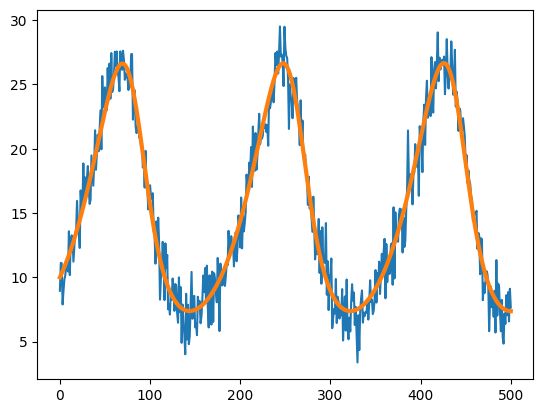

In [20]:
yn = Y[::100,0] + np.random.randn(Y[::100,0].shape[0])*1.5

plt.plot(yn)
plt.plot(Y[::100,0], linewidth=3)
plt.show()

In [12]:
# get finite difference matrix
D = np.zeros((len(yn), len(yn)))
for i in range(len(yn)):
    D[i,i]   = -2
    D[i,i-1] = 1

    if i+1 < len(yn):
        D[i,i+1] = 1
    else:
        D[i,0] = 1

Solution can also be computed analytically. Compare with lecture:
$$
\begin{align}
\theta^* &= (X^TX + \lambda D^TD)^{-1}X^Ty\\
&= (I + \lambda D^TD)^{-1}Iy
\end{align}
$$

In [13]:
lamb  = 5000
y_hat = np.linalg.inv(np.eye(len(yn)) + lamb*D.T@D)@yn[:,None]

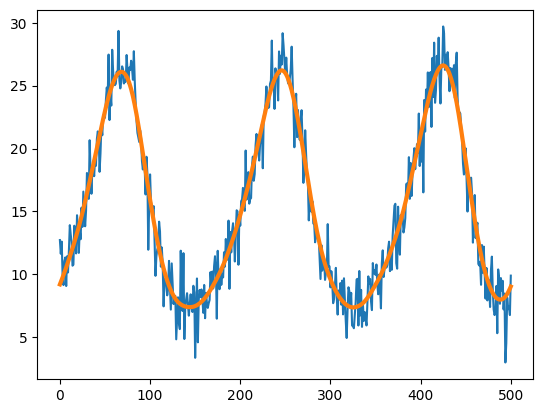

In [15]:
plt.plot(yn)
plt.plot(y_hat, linewidth=3)
plt.show()

**Possible next experiments:**

1) Model Selection: can you find the optimal value of $\lambda$?

2) Model Inference: How good is the parameter estimate after denoising? What are other ways to deal with the noisy data?

3) Ridge Regression: does regularization help with regressing with high order terms?

## Rigde Regression

Fit a polynomial model with Ridge regression
$$
\theta^* = \arg\min_\theta\big\Vert \tilde y - V\theta\big\Vert_2^2 +\lambda\big\Vert\theta\big\Vert_2^2
$$

Remember, we compute Vandermonde matrix
$$
V = \begin{pmatrix}
x_1^0 & x_1^1 & x_1^2 & \dots & x_1^{n-1} \\
x_2^0 & x_2^1 & x_2^2 & \dots & x_2^{n-1} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_n^0 & x_n^1 & x_n^2 & \dots & x_n^{n-1} \\
\end{pmatrix}
$$


In [16]:
def vandermonde(x, degree):
    vander = np.zeros((len(x),degree))
    for i, xi in enumerate(x):
        for d in range(degree):
            vander[i,d] = xi ** d
            
    return vander

def polynomial(x, coeffs):
    V = vandermonde(x, degree=len(coeffs))
    
    return V @ coeffs[:,None]

In [17]:
# construct Vandermonde matrix
V = vandermonde(ts[::100], degree=13)
print(V.shape)

(501, 13)


In [18]:
# estimate theta using regression equation
# regularization can account for degree
lamb = 0 # try 150 instead; what does change?
theta = np.linalg.inv(V.T@V + lamb*np.eye(V.shape[1])) @ V.T @ yn

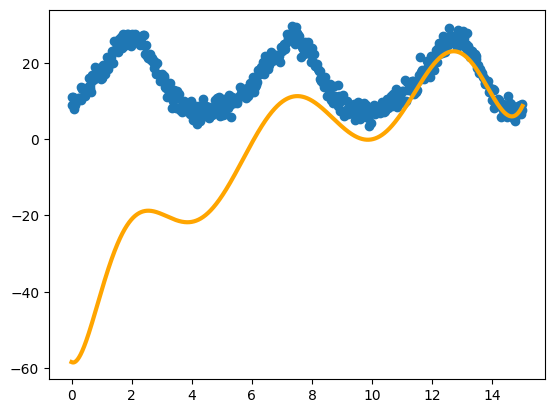

In [21]:
# evaluate polynomial at arbitrary points using coefficients
poly_evaluated = polynomial(ts, theta)

plt.scatter(ts[::100], yn, label="Fitting Data")
plt.plot(ts, poly_evaluated, color='orange', linewidth=3)
plt.show()